#Análisis de tipos de vehiculo año 2025
#Estudiantes:

*   Loreana Conde
*   David Lastre
*   Paul Yaguachi

#  Fase I: Selección de la Fuente de datos

### 📘 Descripción de la fuente:
El dataset es "Cars Datasets (2025)" de Kaggle, el cual se trata de un dataset que presenta características técnicas y comerciales de automóviles del año 2025, y que representa una fuente para el análisis del mercado automotriz actual.
La estructura del dataset incluye tanto variables categóricas (marca, modelo, combustible) como numéricas (precio, potencia, velocidad, aceleración), proporcionando una base importante para realizar un análisis exploratorio.

Fuente: https://www.kaggle.com/datasets/abdulmalik1518/cars-datasets-2025/data?select=Cars+Datasets+2025.csv

### 🎯 Objetivos de investigación
El objetivo de este análisis busca identificar patrones y relaciones existentes en el mercado automotriz para el periodo 2025.
- Evaluar la marca con mayor valor de precio de vehiculo.
- Evaluar las relaciones entre características como potencia y valor de precio de vehiculo.
- Verificar si el número de asientos influye en la velocidad de un determindo auto.

#  Fase II: Adquisición de datos

## 🔧 1. Librerías necesarias y funciones comunes

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import re
sns.set(style='whitegrid')

def print_title(titulo):
    print("\n" + "="*50)
    print(f"{titulo.upper()}")
    print("="*50)

def print_subtitle(subtitulo):
    print("\n")
    print(f"{subtitulo.upper()}")
    print("-"*40)

## 📊 2. Cargar dataset

In [48]:
"""
Fuente de datos origen: Cars Datasets (2025)
URL de datos origen: https://www.kaggle.com/datasets/abdulmalik1518/cars-datasets-2025/data
Método de acceso: Descarga directa desde Kaggle
Tipo de archivo: CSV comprimido en ZIP
Nombre archivo original: Cars Datasets 2025.csv
"""

"""
Por motivos académicos, para realizar este ejercicio se realizó la conversión
de formato (CSV → JSON) para facilitar su carga y uso en  este análisis.

El archivo JSON generado en base al archivo original CSV fue subido a un repositorio github publico para su
acceso medinate la libreria request.
Url: https://github.com/PaulMarcelo/DataScienceUIDE/tree/feature/EjerciciosPaul/Week2/Data_Ejercicio_%20Aplicacion_Autonomo_w2
"""

print_title("INICIA CARGA DE DATOS")
url_origin = "https://raw.githubusercontent.com/PaulMarcelo/DataScienceUIDE/refs/heads/feature/EjerciciosPaul/Week2/Data_Ejercicio_%20Aplicacion_Autonomo_w2/CarsDatasets2025.json"
print(f"\n🔄 Consultando url del archivo: CarsDatasets2025.csv")
response = requests.get(url_origin)
print(f"\n🌐 Código de estado respuesta: {response.status_code}")
if response.status_code == 200:
  try:
      data = response.json()
      df_cars = pd.DataFrame(data['data'])
      print(f"✅ Archivo cargado exitosamente.")
  except ValueError as e:
      print(f"❌ El contenido no es JSON válido: {str(e)}")
else:
    print(f"❌ Error al descargar el archivo")



INICIA CARGA DE DATOS

🔄 Consultando url del archivo: CarsDatasets2025.csv

🌐 Código de estado respuesta: 200
✅ Archivo cargado exitosamente.


#  Fase III: Limpieza y Exploración Inicial (Análisis Exploratorio de Datos - EDA)

## 🔍 1. Exploración Inicial

In [49]:
# Requisito 1: Mostrar las primeras filas (.head())
print_title("📊 1. PRIMERAS FILAS DEL DATASET (.head())")
display(df_cars.head())

# Requisito 2: Utilizar .info() para ver tipos de datos y valores no nulos
print_title("📋 2. INFORMACIÓN GENERAL DEL DATASET (.info())")
df_cars.info()
print(f"\n📈 Resumen de información:")
print(f"   • Número total de filas: {df_cars.shape[0]:,}")
print(f"   • Número total de columnas: {df_cars.shape[1]}")

# Requisito 3: Usar .describe() para estadísticas descriptivas
print_title("📊 3. ESTADÍSTICAS DESCRIPTIVAS (.describe())")
display(df_cars.describe())

# Requisito 4: Identificar y cuantificar valores nulos (.isnull().sum())
print_title("🔍 4. ANÁLISIS DE VALORES NULOS (.isnull().sum())")
# Conteo de valores nulos
total_nulls = (df_cars.isnull().sum()).sum()
print(f"Total de valores nulos: {total_nulls}")
df_cars.isnull().sum()



📊 1. PRIMERAS FILAS DEL DATASET (.HEAD())


,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm



📋 2. INFORMACIÓN GENERAL DEL DATASET (.INFO())
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company Names              1218 non-null   object
 1   Cars Names                 1218 non-null   object
 2   Engines                    1218 non-null   object
 3   CC/Battery Capacity        1215 non-null   object
 4   HorsePower                 1218 non-null   object
 5   Total Speed                1218 non-null   object
 6   Performance(0 - 100 )KM/H  1212 non-null   object
 7   Cars Prices                1218 non-null   object
 8   Fuel Types                 1218 non-null   object
 9   Seats                      1218 non-null   object
 10  Torque                     1217 non-null   object
dtypes: object(11)
memory usage: 104.8+ KB

📈 Resumen de información:
   • Número total de filas: 1,218
   • Número total de colum

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
count,1218,1218,1218,1215,1218,1218,1212,1218,1218,1218,1217
unique,37,1201,356,311,456,114,180,535,23,19,263
top,Nissan,Mistral,I4,1984 cc,355 hp,250 km/h,6.5 sec,"$35,000",Petrol,5,400 Nm
freq,149,2,64,31,23,145,45,36,871,692,72



🔍 4. ANÁLISIS DE VALORES NULOS (.ISNULL().SUM())
Total de valores nulos: 10


,0
Company Names,0
Cars Names,0
Engines,0
CC/Battery Capacity,3
HorsePower,0
Total Speed,0
Performance(0 - 100 )KM/H,6
Cars Prices,0
Fuel Types,0
Seats,0


## 🧹 2. Limpieza de **datos**

In [50]:
print_title("🧹 LIMPIEZA DE DATOS")

print_subtitle("🏷️  TÉCNICA 1: Eliminación de valores nulos")
total_nulls = (df_cars.isnull().sum()).sum()
print(f"Total de valores nulos: {total_nulls}")
print("""
Justificación: Existen solo 10 registros nulos sobre 1218, que es un valor muy bajo.
Eliminar los 10 registros con nulos implica un impacto mínimo sobre el conjunto de datos
y esto puede evitar procesos de imputación inapropiada.\n
""")
print("_"*40)

print(f"\n🔄 Eliminando valores nulos")
df_cars.dropna(inplace=True)
print(f"✅ Valores nulos eliminados exitosamente, verificación:")
df_cars.isnull().sum()


🧹 LIMPIEZA DE DATOS


🏷️  TÉCNICA 1: ELIMINACIÓN DE VALORES NULOS
----------------------------------------
Total de valores nulos: 10

Justificación: Existen solo 10 registros nulos sobre 1218, que es un valor muy bajo.
Eliminar los 10 registros con nulos implica un impacto mínimo sobre el conjunto de datos
y esto puede evitar procesos de imputación inapropiada.


________________________________________

🔄 Eliminando valores nulos
✅ Valores nulos eliminados exitosamente, verificación:


,0
Company Names,0
Cars Names,0
Engines,0
CC/Battery Capacity,0
HorsePower,0
Total Speed,0
Performance(0 - 100 )KM/H,0
Cars Prices,0
Fuel Types,0
Seats,0


In [51]:
print_subtitle("🏷️  TÉCNICA 2: Renombrar y estandarizar columnas")
print("""
Justificación: Se realiza la eliminación de espacios en blanco y
caracteres especiales para una mejor estandarización
""")
print("_"*40+"\n")
# Mostrar nombres originales
print("Nombres de columnas originales:")
for i, col in enumerate(df_cars.columns):
    print(f"\t{i+1:2d}. '{col}'")

# Funcion para reemplazar caracteres en nombres de columnas
def replace_character_column_name(old_char, new_char):
    df_cars.columns = [col.replace(old_char, new_char) for col in df_cars.columns]

# Se renombra columnas
df_cars.columns = [col.lower().strip() for col in df_cars.columns]
replace_character_column_name(' ', '_') # Reemplazar espacios con guiones bajos
replace_character_column_name('/', '_') # Reemplazar barras con guiones bajos
replace_character_column_name('(', '')  # Eliminar caracter
replace_character_column_name(')', '')  # Eliminar caracter
replace_character_column_name('-', '')  # Eliminar caracter

print("Nombres de columnas renombrados:")
for i, col in enumerate(df_cars.columns):
    print(f"\t{i+1:2d}. '{col}'")

print("DataSet luego de renombrado:")
df_cars.head()



🏷️  TÉCNICA 2: RENOMBRAR Y ESTANDARIZAR COLUMNAS
----------------------------------------

Justificación: Se realiza la eliminación de espacios en blanco y
caracteres especiales para una mejor estandarización

________________________________________

Nombres de columnas originales:
	 1. 'Company Names'
	 2. 'Cars Names'
	 3. 'Engines'
	 4. 'CC/Battery Capacity'
	 5. 'HorsePower'
	 6. 'Total Speed'
	 7. 'Performance(0 - 100 )KM/H'
	 8. 'Cars Prices'
	 9. 'Fuel Types'
	10. 'Seats'
	11. 'Torque'
Nombres de columnas renombrados:
	 1. 'company_names'
	 2. 'cars_names'
	 3. 'engines'
	 4. 'cc_battery_capacity'
	 5. 'horsepower'
	 6. 'total_speed'
	 7. 'performance0__100_km_h'
	 8. 'cars_prices'
	 9. 'fuel_types'
	10. 'seats'
	11. 'torque'
DataSet luego de renombrado:


,company_names,cars_names,engines,cc_battery_capacity,horsepower,total_speed,performance0__100_km_h,cars_prices,fuel_types,seats,torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm


In [53]:
print_subtitle("🏷️  TÉCNICA 3: Cambio de tipo de datos")
print("""
Justificación: Debido a que los valores contienen caracteres no numéricos
(como $, cc o texto adicional), no es posible convertirlos
directamente de object a int o float.

Se analiza que es necesario realizar un procesamiento de datos  para extraer
los valores relevantes, garantizando una conversión correcta y evitando errores.
""")
print("_"*40+"\n")



🏷️  TÉCNICA 3: CAMBIO DE TIPO DE DATOS
----------------------------------------

Justificación: Debido a que los valores contienen caracteres no numéricos
(como $, cc o texto adicional), no es posible convertirlos
directamente de object a int o float.

Se analiza que es necesario realizar un procesamiento de datos  para extraer
los valores relevantes, garantizando una conversión correcta y evitando errores.

________________________________________



#  Fase IV: Transformación y Procesamiento de Datos

## 📁 1. Filtrado y Ordenamiento

In [54]:
print_subtitle("🏷️  Filtrado ")
#Creación de Nuevas Columnas: Usar apply(), funciones lambda,
# Eliminar texto "cc", comas y convertir a float
df_cars['cc_battery_capacity_clean'] = (
    df_cars['cc_battery_capacity']
    .str.replace('cc', '', regex=False)      # quitar "cc"
    .str.replace(',', '', regex=False)       # quitar comas
    .str.strip()                             # quitar espacios
)

# Convertir a tipo numérico.
df_cars['cc_battery_capacity_clean'] = pd.to_numeric(df_cars['cc_battery_capacity_clean'], errors='coerce')

# Elimina las filas donde la columna tenga valores nulos
#df_cars.dropna(subset=['cc_battery_capacity_clean'], inplace=True)
print(f"\n🔄 Filtrado de datos")
# Se crear la columna "motor_categoria" para filtrar los datos de cc_battery_capacity_clean
# por categorias de Compacto, Mediano, Alto Rendimine
df_cars['motor_categoria'] = df_cars['cc_battery_capacity_clean'].apply(
    lambda x: (
        'Compacto' if x <= 1600 else
        'Mediano' if x <= 3000 else
        'Alto Rendimiento' if x <= 5000 else
        'Extremo'
    )
)

print(f"Conjunto de datos con nueva columna 'motor_categoria': ")
print("""
Asignación de categoria por filtrado de la columna 'cc_battery_capacity_clean':
  • Compacto: cc <= 1600
  • Mediano: cc <= 3000
  • Alto Rendimiento: cc <= 5000
  • Extremo: cc > 5000
""")
display(df_cars.head())




🏷️  FILTRADO 
----------------------------------------

🔄 Filtrado de datos
Conjunto de datos con nueva columna 'motor_categoria': 

Asignación de categoria por filtrado de la columna 'cc_battery_capacity_clean':
  • Compacto: cc <= 1600
  • Mediano: cc <= 3000
  • Alto Rendimiento: cc <= 5000
  • Extremo: cc > 5000



,company_names,cars_names,engines,cc_battery_capacity,horsepower,total_speed,performance0__100_km_h,cars_prices,fuel_types,seats,torque,cc_battery_capacity_clean,motor_categoria
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm,3990.0,Alto Rendimiento
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm,6749.0,Extremo
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm,1200.0,Compacto
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm,3982.0,Alto Rendimiento
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm,5204.0,Extremo


In [55]:
print_subtitle("🏷️  Creacion y ordenamiento de la columna nueva cars_prices_value")

print(f"\n🔄 Procesamiento de datos")
# Se crea una copia auxiliar para mostrar valores antes y después
df_cars['cars_prices_original'] = df_cars['cars_prices']

def limpiar_y_convertir_precio(valor):
    # Elimina símbolos y espacios
    valor = str(valor).replace('$', '').replace(',', '').strip()

    # Si es un rango, promedia ambos extremos
    if '-' in valor:
        try:
            partes = valor.split('-')
            nums = [float(p.strip()) for p in partes if p.strip().isdigit()]
            if len(nums) == 2:
                return sum(nums) / 2
        except:
            return np.nan
    else:
        try:
            return float(valor)
        except:
            return np.nan

# Aplica la función
df_cars['cars_prices_value'] = df_cars['cars_prices'].apply(limpiar_y_convertir_precio)

# Muestra los primeros valores antes y después de convertir
print("\n🔍 Ejemplos de conversión de 'cars_prices_value':\n")
for i in range(20):
    original = df_cars.iloc[i]['cars_prices_original']
    convertido = df_cars.iloc[i]['cars_prices_value']
    print(f"  • Original: {original}  →  Convertido: {convertido:.2f}")

# Verificación
print(" Conversión completada. Tipo de dato:")
print(df_cars['cars_prices_value'].dtype)
print("\n Estadísticas descriptivas:")
print(df_cars['cars_prices_value'].describe())

print_subtitle(" ---- Ordenamiento ------")
# Ordenar el DataFrame por 'cars_prices_value' de forma descendente
df_ordenado = df_cars.sort_values(by='cars_prices_value', ascending=False)
print("Dataset ordenado (DESC) por la columna  'cars_prices_value' (primeras 5 filas):")
display(df_ordenado.head())

# Filtrar por cars_prices_value mayor a 4000
df_filtro = df_cars[df_ordenado['cars_prices_value'] > 4000]
print("-"*50)
print("\nTop 5 de vehiculos con precio mayor a $4000:")
print("-"*50)
display(df_filtro.head())




🏷️  CREACION Y ORDENAMIENTO DE LA COLUMNA NUEVA CARS_PRICES_VALUE
----------------------------------------

🔄 Procesamiento de datos

🔍 Ejemplos de conversión de 'cars_prices_value':

  • Original: $1,100,000   →  Convertido: 1100000.00
  • Original: $460,000   →  Convertido: 460000.00
  • Original: $12,000-$15,000  →  Convertido: 13500.00
  • Original: $161,000   →  Convertido: 161000.00
  • Original: $253,290   →  Convertido: 253290.00
  • Original: $499,000   →  Convertido: 499000.00
  • Original: $193,440   →  Convertido: 193440.00
  • Original: $311,000   →  Convertido: 311000.00
  • Original: $4,500,000   →  Convertido: 4500000.00
  • Original: $280,000   →  Convertido: 280000.00
  • Original: $350,000   →  Convertido: 350000.00
  • Original: $210,000   →  Convertido: 210000.00
  • Original: $230,000   →  Convertido: 230000.00
  • Original: $1,700,000   →  Convertido: 1700000.00
  • Original: $280,000   →  Convertido: 280000.00
  • Original: $220,000   →  Convertido: 220000.00


,company_names,cars_names,engines,cc_battery_capacity,horsepower,total_speed,performance0__100_km_h,cars_prices,fuel_types,seats,torque,cc_battery_capacity_clean,motor_categoria,cars_prices_original,cars_prices_value
887,Bugatti,La Voiture Noire,8.0L Quad-Turbo W16,7993 cc,1500 hp,420 km/h,2.5 sec,"$18,000,000",Petrol,2,1600 Nm,7993.0,Extremo,"$18,000,000",18000000.0
886,Bugatti,Centodieci,8.0L Quad-Turbo W16,7993 cc,1600 hp,380 km/h,2.4 sec,"$9,000,000",Petrol,2,1600 Nm,7993.0,Extremo,"$9,000,000",9000000.0
1212,Mazda,787B (Race Car),2.6L Wankel Rotary Engine,"2,620 cc",700 hp,320 km/h,3.5 sec,"$5,000,000 - $7,000,000",Petrol,1,500 Nm,2620.0,Mediano,"$5,000,000 - $7,000,000",6000000.0
885,Bugatti,Divo,8.0L Quad-Turbo W16,7993 cc,1500 hp,380 km/h,2.4 sec,"$5,800,000",Petrol,2,1600 Nm,7993.0,Extremo,"$5,800,000",5800000.0
889,Bugatti,Mistral,8.0L Quad-Turbo W16,7993 cc,1600 hp,420 km/h,2.4 sec,"$5,000,000",Petrol,2,1600 Nm,7993.0,Extremo,"$5,000,000",5000000.0


--------------------------------------------------

Top 5 de vehiculos con precio mayor a $4000:
--------------------------------------------------


/tmp/ipython-input-55-934025298.py:49: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_filtro = df_cars[df_ordenado['cars_prices_value'] > 4000]


,company_names,cars_names,engines,cc_battery_capacity,horsepower,total_speed,performance0__100_km_h,cars_prices,fuel_types,seats,torque,cc_battery_capacity_clean,motor_categoria,cars_prices_original,cars_prices_value
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm,3990.0,Alto Rendimiento,"$1,100,000",1100000.0
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm,6749.0,Extremo,"$460,000",460000.0
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm,1200.0,Compacto,"$12,000-$15,000",13500.0
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm,3982.0,Alto Rendimiento,"$161,000",161000.0
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm,5204.0,Extremo,"$253,290",253290.0


## 📁 2. Agrupamiento (groupby)

In [56]:
print_title("🏷️  Agrupación de datos por una o más columnas y apliación de funciones de agregación (mean, sum, count, median, etc.)")

print('1.- PROMEDIO DE ASIENTOS POR VEHICULO Y TIPO DE MOTOR')

# Funcion para obtener los primeros valores de la columna df_cars['seats'],
# para este caso se define solo tomar el primer valor encontrado en el dato original.
def get_first_value(value):
  if isinstance(value, str): # verifica si 'value' es un texto
    match = re.search(r'\d+', value) # valida expresion regular para obtener el primer valor encontrado
    return int(match.group()) # se obtiene el valor y se procesa a int
  return 0

# Se crea una nueva columna 'seats_value', aplicando la función get_first_value
# para obtener solo el valor numerico del asiento
print(f"\n🔄 Creando nueva columna 'seats_value'")
df_cars['seats_value'] = df_cars['seats'].apply(get_first_value)
#display(df_cars.head())

print(f"\n✅ Promedio de asientos por vehiculo y tipo de motor:")
mean_cars_names_by_seats = df_cars.groupby(['cars_names','engines'])['seats_value'].agg(['mean']).reset_index()
display(mean_cars_names_by_seats.head(10))




🏷️  AGRUPACIÓN DE DATOS POR UNA O MÁS COLUMNAS Y APLIACIÓN DE FUNCIONES DE AGREGACIÓN (MEAN, SUM, COUNT, MEDIAN, ETC.)
1.- PROMEDIO DE ASIENTOS POR VEHICULO Y TIPO DE MOTOR

🔄 Creando nueva columna 'seats_value'

✅ Promedio de asientos por vehiculo y tipo de motor:


,cars_names,engines,mean
0,GT 63 S,V8,4.0
1,100NX,1.6L Inline-4,4.0
2,114D,I3,5.0
3,114D SPORT LINE,I3,5.0
4,114i,I4,5.0
5,116D,I3,5.0
6,116D ADVANTAGE,I3,5.0
7,116D EFFICIENTDYNAMICS,I3,5.0
8,116i,I3,5.0
9,116i EFFICIENTDYNAMICS,I4,5.0


In [57]:
print('2.- TOTAL VEHICULOS POR TIPO DE CONBUSTIBLE')
print(f"\n🔄 Procesando datos'")
total_card_by_fuel_type = df_cars.groupby(['fuel_types'])['cars_names'].agg(['count']).reset_index()
print(f"\n✅ Total autos por tipo de conbustible:")
total_card_by_fuel_type.head()

2.- TOTAL VEHICULOS POR TIPO DE CONBUSTIBLE

🔄 Procesando datos'

✅ Total autos por tipo de conbustible:


,fuel_types,count
0,CNG/Petrol,1
1,Diesel,102
2,Diesel/Petrol,4
3,Electric,95
4,Gas / Hybrid,1


In [58]:
print_subtitle("🏷️  Creacion de la columna nueva horsepower_value")
print(f"\n🔄 Procesando datos'")
# Funcion para limpiar los datos del texto ingresado 'hp_str'
def clean_horsepower(valor):
    valor = str(valor)
    # Buscar todos los números en la cadena (incluye decimales)
    numeros = re.findall(r'\d+\.?\d*', valor.replace(',', ''))
    if '-' in valor and len(numeros) >= 2:
        try:
            nums = [float(n) for n in numeros[:2]]  # Solo toma los primeros dos números
            return sum(nums) / 2
        except:
            return np.nan
    elif numeros:
        try:
            return float(numeros[0])  # Solo el primer número
        except:
            return np.nan
    else:
        return np.nan


# Aplicar la función de limpieza
df_cars['horsepower_value'] = df_cars['horsepower'].apply(clean_horsepower)
print(f"\n✅ Datos procesados.")



🏷️  CREACION DE LA COLUMNA NUEVA HORSEPOWER_VALUE
----------------------------------------

🔄 Procesando datos'

✅ Datos procesados.


In [59]:
print_subtitle("🏷️  Creacion de la columna nueva total_speed_value")
print(f"\n🔄 Procesando datos'")

# Aplicar la función de limpieza
df_cars['total_speed_value'] = df_cars['total_speed'].apply(clean_horsepower)
print(f"\n✅ Datos procesados.")



🏷️  CREACION DE LA COLUMNA NUEVA TOTAL_SPEED_VALUE
----------------------------------------

🔄 Procesando datos'

✅ Datos procesados.


## 📁 4. Reorganización de Datos

In [60]:
print_subtitle("🏷️  Reorganización de Datos: Utilizar pivot_table()")

print(f"\n🔄 Procesamiento de datos")
pivot_table_company_carname = df_cars.pivot_table(index='company_names', columns='cars_names', values='cars_prices_value', aggfunc='mean')
pivot_table_company_carname = pivot_table_company_carname.dropna(axis=0, how='all')
pivot_table_company_carname = pivot_table_company_carname.dropna(axis=1, how='all')
pivot_clean = pivot_table_company_carname.round(0).fillna("No disponible")
print("\nPivot table: Promedio de precios vehiculo por nombre compania y nombre de vehiculo:")
display(pivot_clean.head())



🏷️  REORGANIZACIÓN DE DATOS: UTILIZAR PIVOT_TABLE()
----------------------------------------

🔄 Procesamiento de datos

Pivot table: Promedio de precios vehiculo por nombre compania y nombre de vehiculo:


cars_names,GT 63 S,100NX,114D,114D SPORT LINE,114i,116D,116D ADVANTAGE,116D EFFICIENTDYNAMICS,116i,116i EFFICIENTDYNAMICS,...,Z (Fairlady Z),Z PROTO,Zest,e-2008,e-2008 GT,e-208,eK Space,eK X,i (Kei Car),i-MiEV (Electric)
company_names,,,,,,,,,,,,,,,,,,,,,
ASTON MARTIN,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,...,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible
AUDI,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,...,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible
Acura,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,...,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible
BENTLEY,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,...,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible
BMW,No disponible,No disponible,27000.0,28000.0,26000.0,30000.0,31000.0,30000.0,28000.0,29000.0,...,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible,No disponible


#  Fase V: Análisis y Presentación de Insights Preliminares

## 🤔 1. Analisis

In [61]:
print_subtitle("🤔 1.- Pregunta: Cual es la marca con mayor valor de precio de vehiculo ?")

print(f"\n🔄 Procesando datos")
# Se agrupa datos por 'company_names' para obtener el maximo valor de 'cars_prices_value'
df_max_price_by_company = df_cars.groupby('company_names')['cars_prices_value'].max().reset_index()
# Se realiza la combinación de los datos entre 'df_cars' y 'df_max_price_by_company'
# para encontrar el nombre del coche que tiene un precio máximo.
df_result = pd.merge(df_max_price_by_company, df_cars, on=['company_names', 'cars_prices_value'], how='inner')
# Se elimina duplicados y se reordena los datos
df_result = df_result[['company_names', 'cars_names', 'cars_prices_value']].drop_duplicates()
df_result_sorted = df_result.sort_values(by='cars_prices_value', ascending=False).reset_index(drop=True)
print(f"\n✅ Top 5 de marcas de vehiculos y sus precios:")
display(df_result_sorted.head())
print(f"\n💡 Respuesta:")
print("""
En base al procesamiento de los datos podemos identificar que la marca
con el vehiculo cuyo precio es el más alto del mercado, es 'Bugatti' con su modelo
'La Voiture Noire' con un precio de	$18000000.0
""")
#obtener las caracteristicas del carro Bugatti	La Voiture Noire
info_bugatti_voiture_noire = df_cars[(df_cars['company_names'] == 'Bugatti') & (df_cars['cars_names'] == 'La Voiture Noire')]
info_bugatti_voiture_noire = info_bugatti_voiture_noire.iloc[0]
info_bugatti_voiture_noire = info_bugatti_voiture_noire.drop(['cc_battery_capacity_clean', 'cars_prices_original','cars_prices_value','seats_value'])
print("\nInformación del carro Bugatti La Voiture Noire:")
display(info_bugatti_voiture_noire)





🤔 1.- PREGUNTA: CUAL ES LA MARCA CON MAYOR VALOR DE PRECIO DE VEHICULO ?
----------------------------------------

🔄 Procesando datos

✅ Top 5 de marcas de vehiculos y sus precios:


,company_names,cars_names,cars_prices_value
0,Bugatti,La Voiture Noire,18000000.0
1,Mazda,787B (Race Car),6000000.0
2,LAMBORGHINI,VENENO ROADSTER,4500000.0
3,ASTON MARTIN,VALKYRIE,3200000.0
4,FERRARI,MONZA SP2,1700000.0



💡 Respuesta:

En base al procesamiento de los datos podemos identificar que la marca
con el vehiculo cuyo precio es el más alto del mercado, es 'Bugatti' con su modelo
'La Voiture Noire' con un precio de	$18000000.0


Información del carro Bugatti La Voiture Noire:


,887
company_names,Bugatti
cars_names,La Voiture Noire
engines,8.0L Quad-Turbo W16
cc_battery_capacity,7993 cc
horsepower,1500 hp
total_speed,420 km/h
performance0__100_km_h,2.5 sec
cars_prices,"$18,000,000"
fuel_types,Petrol
seats,2



 GRAFICOS


📈 GRÁFICO 1: TOP 10 MARCAS CON VEHÍCULOS MÁS CAROS
----------------------------------------

💡 Interpretación Grafico:

El gráfico muestra que Bugatti lidera con un amplio margen. 
Esto confirma que las marcas enfocadas en lujo y performance dominan 
los precios más altos del mercado automotriz.



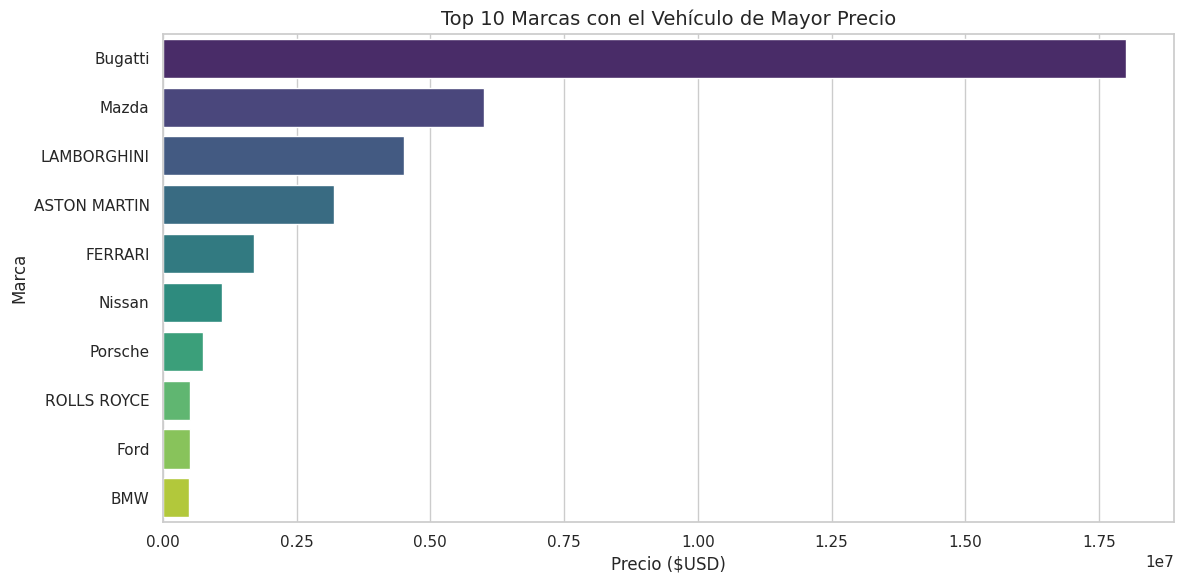

In [62]:
print_title(" Graficos")
print_subtitle("📈 Gráfico 1: Top 10 marcas con vehículos más caros")

print(f"\n💡 Interpretación Grafico:")
print("""
El gráfico muestra que Bugatti lidera con un amplio margen.
Esto confirma que las marcas enfocadas en lujo y performance dominan
los precios más altos del mercado automotriz.
""")

# Agrupar por marca y tomar el vehículo más caro de cada una
df_result = df_cars.groupby('company_names', as_index=False)['cars_prices_value'].max()

# Ordenar de mayor a menor
df_result_sorted = df_result.sort_values(by='cars_prices_value', ascending=False)

# Visualizar Top 10 por precio
top_10_precios = df_result_sorted.head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_10_precios,
    y='company_names',
    x='cars_prices_value',
    hue='company_names',
    palette='viridis',
    legend=False
)
plt.title('Top 10 Marcas con el Vehículo de Mayor Precio', fontsize=14)
plt.xlabel('Precio ($USD)')
plt.ylabel('Marca')
plt.tight_layout()
plt.show()



📈 GRÁFICO 2: RELACIÓN ENTRE CABALLOS DE FUERZA (HP) Y VALOR DE VENTA DE VEHÍCULOS
----------------------------------------

💡 Interpretación Grafico:

- La mayoría de los vehículos están concentrados en la zona baja izquierda: esto indica que la mayoría tiene potencia baja/media (100-700 HP) 
y precio bajo o medio.
- Algunos puntos están muy separados arriba/derecha, lo que significa que hay autos con potencia muy alta (más de 1000 HP) y precio muy alto (hasta 18 millones).
- En general, mayor potencia → mayor precio, pero hay excepciones.
- Las marcas de lujo dominan la parte superior del gráfico.
- Marcas como Ford, Hyundai, Honda, Toyota tienen muchos puntos abajo y a la izquierda: 
  autos baratos y con potencia baja/media, lo esperado en autos comerciales.




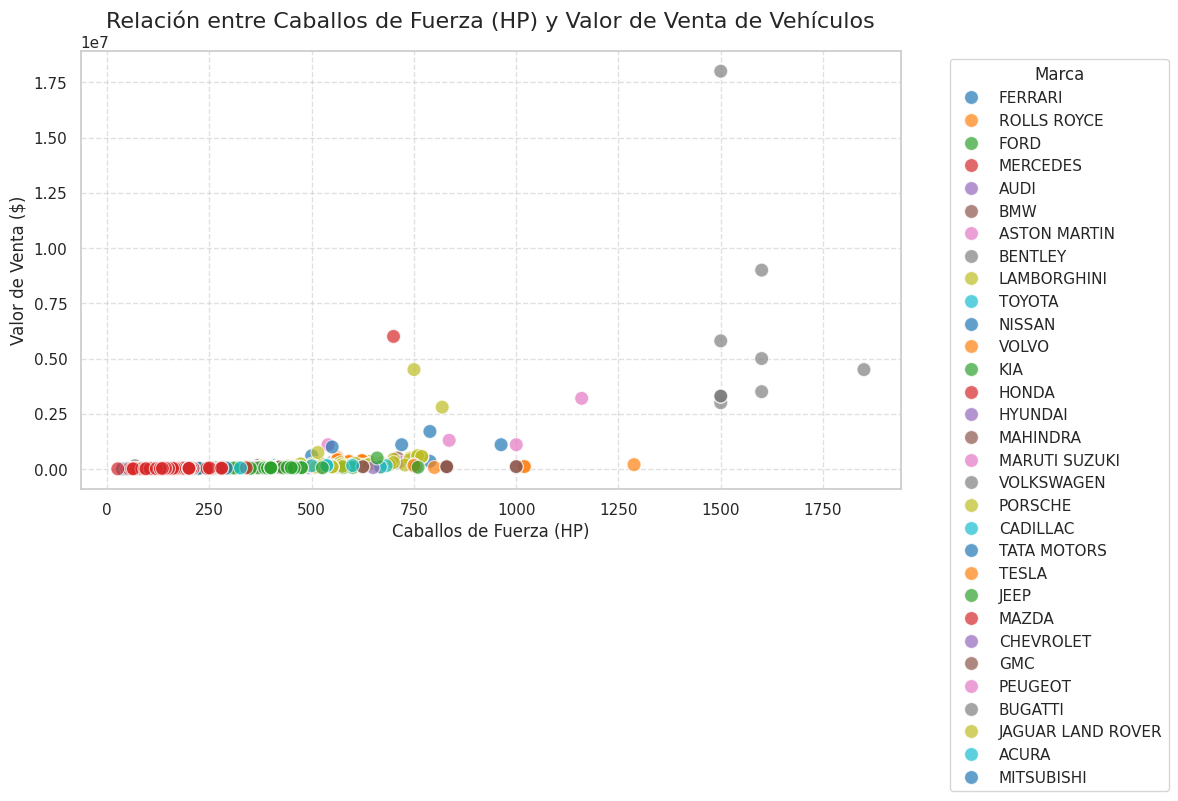

In [64]:
print_subtitle("📈 Gráfico 2: Relación entre Caballos de Fuerza (HP) y Valor de Venta de Vehículos")

print(f"\n💡 Interpretación Grafico:")
print("""
- La mayoría de los vehículos están concentrados en la zona baja izquierda: esto indica que la mayoría tiene potencia baja/media (100-700 HP)
y precio bajo o medio.
- Algunos puntos están muy separados arriba/derecha, lo que significa que hay autos con potencia muy alta (más de 1000 HP) y precio muy alto (hasta 18 millones).
- En general, mayor potencia → mayor precio, pero hay excepciones.
- Las marcas de lujo dominan la parte superior del gráfico.
- Marcas como Ford, Hyundai, Honda, Toyota tienen muchos puntos abajo y a la izquierda:
  autos baratos y con potencia baja/media, lo esperado en autos comerciales.

""")


# Eliminar filas con valores nulos en las columnas clave para este análisis
df_cars['company_names'] = df_cars['company_names'].str.upper().str.strip()
df_cars.dropna(subset=['horsepower_value', 'cars_prices_value'], inplace=True)

plt.figure(figsize=(12, 7)) # Establece el tamaño de la figura para el gráfico
sns.scatterplot(
    x='horsepower_value',     # Datos para el eje X (Caballos de Fuerza)
    y='cars_prices_value',    # Datos para el eje Y (Valor de Venta)
    data=df_cars,             # DataFrame de donde se toman los datos
    hue='company_names',      # Color de los puntos basado en la marca del coche
    palette='tab10',          # Paleta de colores para las marcas
    s=100,                    # Tamaño de los puntos
    alpha=0.7                 # Transparencia de los puntos para ver superposiciones
)

# Configuración de los elementos del gráfico
plt.title('Relación entre Caballos de Fuerza (HP) y Valor de Venta de Vehículos', fontsize=16)
plt.xlabel('Caballos de Fuerza (HP)', fontsize=12)
plt.ylabel('Valor de Venta ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) # Añade una cuadrícula suave

# Mueve la leyenda fuera del área de trazado para que no tape los puntos
plt.legend(title='Marca', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()




📈 GRÁFICO 3: RELACIÓN ENTRE VELOCIDAD SEGÚN NÚMERO DE ASIENTOS
----------------------------------------

💡 Interpretación Grafico:

- Sí hay influencia del número de asientos en la velocidad.
- Menos asientos tiende a autos más rápidos (autos deportivos, superautos).
- Más asientos tiende a autos más lentos, pensados para confort o transporte de más personas.
- Se puede inferir que el diseño de autos rápidos prioriza tener pocos asientos para reducir peso y tamaño.




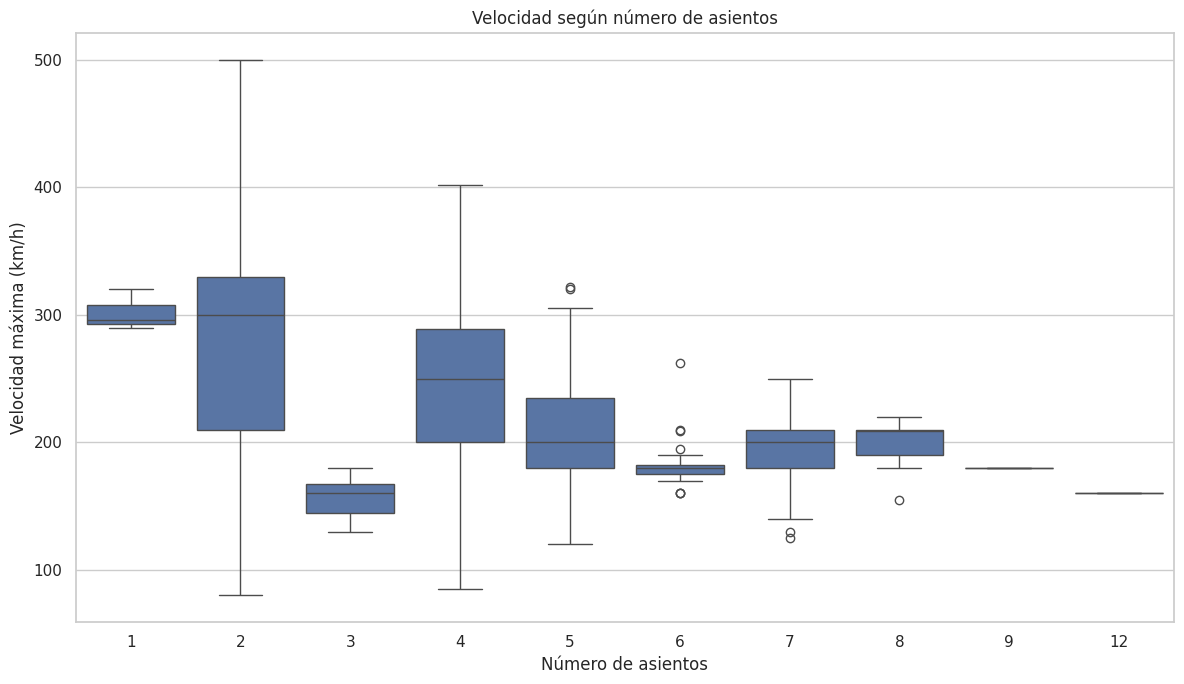

In [65]:
print_subtitle("📈 Gráfico 3: Relación entre Velocidad según número de asientos")

print(f"\n💡 Interpretación Grafico:")
print("""
- Sí hay influencia del número de asientos en la velocidad.
- Menos asientos tiende a autos más rápidos (autos deportivos, superautos).
- Más asientos tiende a autos más lentos, pensados para confort o transporte de más personas.
- Se puede inferir que el diseño de autos rápidos prioriza tener pocos asientos para reducir peso y tamaño.

""")

# Grafico boxplot para realizar  este análisis
plt.figure(figsize=(12,7))
sns.boxplot(
    x='seats_value',
    y='total_speed_value',
    data=df_cars
)
plt.title('Velocidad según número de asientos')
plt.xlabel('Número de asientos')
plt.ylabel('Velocidad máxima (km/h)')
plt.tight_layout()
plt.show()

## 🧠 2. Presentación de Insights Preliminares



### **✅ 1.   Se identificó que la marca "Bugatti", con su modelo "La Voiture Noire", tiene el vehículo más costoso del conjunto de datos, con un precio de $18 millones, lo que reafirma su posición en el mercado de lujo extremo.**
### **✅ 2.   En la segmentación por marcas, algunos vehículos de lujo presentan precios elevados pero especificaciones técnicas bajas; esto sugiere que también existen compras basadas únicamente en la marca y no en las características del vehículo.**
### **✅ 3.   También se observó que la mayoría de los vehículos se encuentran en un rango de precios más accesibles, lo que sugiere un mercado con distintos niveles de consumo, desde vehículos económicos hasta vehículos de lujo.**

#  Fase VI: Conclusiones del proceso y análisis de datos




# *Conclusiones del proceso de análisis de datos*
### Durante este proceso de análisis, se tomaron decisiones claves como:
####📌 1. Eliminar registros nulos debido a su baja proporción en el conjunto de datos.
####📌 2. Estandarizar los nombres de las columnas para facilitar el procesamiento y manipulación de los datos.
####📌 3. Limpiar los valores de ciertas columnas, eliminando símbolos y texto irrelevante, con el fin de lograr conversiones numéricas exitosas.
####📌 4. Agrupar y ordenar los datos para facilitar la identificación de información relevante según las categorías de vehículos.
####📌 5. El Análisis Exploratorio de Datos fue fundamental para comprender la estructura y las características de las variables del conjunto de datos antes de realizar análisis más profundos.
####📌 6. Los gráficos resultaron ser herramientas poderosas para identificar tendencias, correlaciones y patrones que no eran evidentes en los datos crudos.
####📌 7. Por último, se considera que es importante contar con el apoyo de expertos en el área automotriz y de ventas, a fin de lograr una interpretación más precisa y contextualizada de los datos.


# *Conclusiones del análisis de datos*

####💡 Nuestro análisis del Cars Datasets (2025) mostró de manera clara que las marcas de automóviles de lujo y alto rendimiento, como Bugatti, Ferrari, Rolls Royce, dominan el segmento de mayor valor de precio. Esto se evidencia por la concentración de sus modelos en los rangos de precios más altos del dataset. Lo cual no solo refleja la exclusividad y el estatus asociado a estas marcas, sino también quizas la incorporación de tecnología avanzada y materiales premium que justifican sus costos elevados.
####Por otro lado el resto de marcas dentro del estudio, aunque con mayor representación en el dataset, se mantienen en rangos de precio significativamente más bajos, confirmando las distintas segmentaciones del mercado.
####En resumen, el análisis permitió tener una idea más clara de la estructura y segmentación del mercado automotriz en lo que va del 2025.
